# Experiments with two-branch models: with rasterio

In [1]:
#check the evironement path
import sys
sys.executable

'/usr/bin/python'

In [2]:
import tensorflow as tf
print(tf.__version__)
import keras
print(keras.__version__)

from keras import backend as K

1.15.2
2.2.4


Using TensorFlow backend.


# Loading Data: Training images + labels

In [3]:
import os
from glob import glob
import numpy as np
import rasterio

import random
from random import randint
random.seed(1337)
np.random.seed(1337)
#tf.set_random_seed(1337)

from keras.utils import to_categorical

In [4]:
path_data="/linux_data/test_S1TS_S2/*/"
data = glob(path_data)


data_tiles_list = []
label_tiles_list = []


data_tiles_list.append(glob(data[1]+ "/*.tif"))
label_tiles_list.append(glob(data[0]+ "/*.tif"))


data_tiles_list = [y for x in data_tiles_list for y in x]
label_tiles_list = [y for x in label_tiles_list for y in x]
print(len(data_tiles_list))
print(len(label_tiles_list))

4518
4518


### Training images

#### First stream: Sentinel-1

#### Time series: 12 months

In [5]:
nb_tiles=10
#nb_tiles=int(len(data_tiles_list)*0.8)

tr_images_s1 = []

for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    
    
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array    
    t = np.concatenate((np.expand_dims(data_in.read(1), axis=2), np.expand_dims(data_in.read(2), axis=2)), axis=2) #expands the array by 1 dimension
    t1 =np.expand_dims(t, axis=0)

    for j in range(3,25,2): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((np.expand_dims(data_in.read(j), axis=2), np.expand_dims(data_in.read(j+1), axis=2)), axis=2)
        t1 = np.concatenate((t1, np.expand_dims(t, axis=0)), axis=0) 
    tr_images_s1.append(t1)
    

training_images_s1 = np.asarray(tr_images_s1) # converts list training_images into an array
del tr_images_s1

print(training_images_s1.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 12, 256, 256, 2)


#### Time series: 7 months

In [6]:
tr_images_s1 = []

for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    
    
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array    
    t = np.concatenate((np.expand_dims(data_in.read(11), axis=2), np.expand_dims(data_in.read(12), axis=2)), axis=2) #expands the array by 1 dimension
    t1 =np.expand_dims(t, axis=0)

    for j in range(13,25,2): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((np.expand_dims(data_in.read(j), axis=2), np.expand_dims(data_in.read(j+1), axis=2)), axis=2)
        t1 = np.concatenate((t1, np.expand_dims(t, axis=0)), axis=0) 
    tr_images_s1.append(t1)
    

training_images_s1 = np.asarray(tr_images_s1) # converts list training_images into an array
del tr_images_s1

print(training_images_s1.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 7, 256, 256, 2)


#### Second stream: Sentinel-2

In [7]:
tr_images_s2 = []


for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    
    
    data_in = rasterio.open(data_tiles_list[i]) #opens the .tif/Raster in an array
    
    t = np.expand_dims(data_in.read(25), axis=2) #expands the array by 1 dimension

    for j in range(26,35): #expands the array by j dimensions and adds them together (concatenate)
        t = np.concatenate((t, np.expand_dims(data_in.read(j), axis=2)), axis=2)
        
    tr_images_s2.append(t)
    

training_images_s2 = np.asarray(tr_images_s2) # converts list training_images into an array
del tr_images_s2

print(training_images_s2.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 256, 256, 10)


### Labels

In [ ]:
# Labels for training
from keras.utils import to_categorical

tr_labels=[]
for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    data_in = rasterio.open(label_tiles_list[i]) #opens the .tif/Raster in an array    
    tr_labels.append(data_in.read(1))
        
training_labels = np.asarray(tr_labels) # converts list training_images into an array
del tr_labels
training_labels = np.expand_dims(training_labels, axis=3)

#One-hot coding labels
training_labels=to_categorical(training_labels)

print(training_labels.shape)

#### Labels for training + calculation of pixel percentage per classes

In [8]:
nb_labels = 18 #should be known in prior
tr_labels=[]
weight=[]

for i in range(nb_tiles):
    print(str(i) + "/" + str(nb_tiles))
    weightspers=[]
    data_in = rasterio.open(label_tiles_list[i]) #opens the .tif/Raster in an array    
    tr_labels.append(data_in.read(1))
    for j in range(nb_labels):
        weightspers.append(np.sum(data_in.read(1)==j))
    weight.append(weightspers)
    
training_labels = np.asarray(tr_labels) # converts list training_images into an array
del tr_labels
training_labels = np.expand_dims(training_labels, axis=3)

#weights=np.sum(weight,axis=0)/(nb_tiles*nb_rows*nb_cols) #percentage of classes

#One-hot coding labels
training_labels=to_categorical(training_labels)

print(training_labels.shape)

0/10
1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
(10, 256, 256, 18)


### Settings of data set parameters

In [9]:
nb_labels = training_labels.shape[3]
print(nb_labels)

timestamps = training_images_s1.shape[1]
print(timestamps)

# The dimensions of the input images
nb_rows = training_images_s2.shape[1]
print(nb_rows)
nb_cols = training_images_s2.shape[2]
print(nb_cols)
channels1= training_images_s1.shape[4]
print(channels1)
channels2= training_images_s2.shape[3]
print(channels2)

if K.image_data_format() == 'channels_first':
    channel_axis = 1
    input_shape1=(timestamps,channels1,nb_rows,nb_cols)    
    input_shape2 = (channels2,nb_rows, nb_cols)
    
if K.image_data_format() == 'channels_last':
    channel_axis = 3
    input_shape1=(timestamps,nb_rows,nb_cols, channels1)
    input_shape2= (nb_rows,nb_cols,channels2)

print(input_shape1)
print(input_shape2)

18
7
256
256
2
10
(7, 256, 256, 2)
(256, 256, 10)


# Model Definition

In [10]:
from keras.layers import Input
from keras.models import Model
#from keras import backend as K
from keras import layers

#######
from keras.layers import BatchNormalization
from keras.layers import Conv2D
from keras.layers import Activation
from keras.layers import Lambda,Add,Reshape
from keras.layers import MaxPooling2D,Dropout


#######
from keras.layers import AlphaDropout
from keras.layers import concatenate
from keras.layers import Conv2DTranspose
from keras.layers import ConvLSTM2D
##
from keras.layers import AtrousConvolution2D

### Elementary blocks

In [11]:
def identity_block(input_tensor, kernel_size, filters, stage, block):
    """The identity block is the block that has no conv layer at shortcut.
    # Arguments
        input_tensor: input tensor
        kernel_size: defualt 3, the kernel size of middle conv layer at main path
        filters: list of integers, the filterss of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
    # Returns
        Output tensor for the block.
    """
    filters1, filters2, filters3 = filters
    if K.image_data_format() == 'channels_last':
        bn_axis = 3
    else:
        bn_axis = 1
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    act_name = 'act' + str(stage) + block

    x = Conv2D(filters1, (1, 1), name=conv_name_base + '2a')(input_tensor)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2a')(x)
    x = Activation('relu')(x)

    x = Conv2D(
        filters2, kernel_size, padding='same', name=conv_name_base + '2b')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2b')(x)
    x = Activation('relu')(x)

    x = Conv2D(filters3, (1, 1), name=conv_name_base + '2c')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2c')(x)

    x = layers.add([x, input_tensor])
    x = Activation('relu', name=act_name)(x)
    return x


def conv_block(input_tensor,
               kernel_size,
               filters,
               stage,
               block,
               strides=(2, 2)):
    """conv_block is the block that has a conv layer at shortcut
    # Arguments
        input_tensor: input tensor
        kernel_size: defualt 3, the kernel size of middle conv layer at main path
        filters: list of integers, the filterss of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
    # Returns
        Output tensor for the block.
    Note that from stage 3, the first conv layer at main path is with strides=(2,2)
    And the shortcut should have strides=(2,2) as well
    """
    filters1, filters2, filters3 = filters
    if K.image_data_format() == 'channels_last':
        bn_axis = 3
    else:
        bn_axis = 1
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    act_name = 'act' + str(stage) + block

    x = Conv2D(
        filters1, (1, 1), strides=strides,
        name=conv_name_base + '2a')(input_tensor)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2a')(x)
    x = Activation('relu')(x)

    x = Conv2D(
        filters2, kernel_size, padding='same', name=conv_name_base + '2b')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2b')(x)
    x = Activation('relu')(x)

    x = Conv2D(filters3, (1, 1), name=conv_name_base + '2c')(x)
    x = BatchNormalization(axis=bn_axis, name=bn_name_base + '2c')(x)

    shortcut = Conv2D(
        filters3, (1, 1), strides=strides,
        name=conv_name_base + '1')(input_tensor)
    shortcut = BatchNormalization(
        axis=bn_axis, name=bn_name_base + '1')(shortcut)

    x = layers.add([x, shortcut])
    x = Activation('relu', name=act_name)(x)
    return x

## New designed architectures

### two_branch_Unet

In [12]:
def two_branch_Unet(input_shape1, input_shape2):  
    """The Definition of the two-branch architecture with one block of ConvLSTM for the timeseries S1 stream and Unet in the S2 stream
        
        # Arguments
        input_shape1: the shape of the input tensor: S1 timeseries
        input_shape2: the shape of the input tensor: S2
        
        # Returns
        the model definition using keras
    """
    inputA = Input(input_shape1, name='input1')
    inputB = Input(input_shape2, name='input2')
    
    N=input_shape2[0]

    #M1: ConvLSTM2D unit
    conv1 = ConvLSTM2D(64, (3, 3), activation='relu', padding='same', return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(inputA) 
    convf = Conv2D(nb_labels, 1, activation = 'softmax',name="M1_output")(conv1)
    
    model1 = Model(inputs=inputA, outputs=[convf])
    
    
    #M2: Unet
    channel_axis = 3
    filter_size = (6, 6)
    blocks = [8,32,32,64,64,128]
    blocks2 = blocks
    activation = 'relu'
    filter_initializer = 'lecun_normal'

    #encoder
    encoder = inputB
    encoder_list = []
    for block_id , n_block in enumerate(blocks):
        with K.name_scope('Encoder_block{0}'.format(block_id)):
            encoder = Conv2D(filters = n_block, kernel_size = filter_size, activation = None, padding = 'same', kernel_initializer = filter_initializer) (encoder)
            encoder = BatchNormalization(axis=channel_axis, momentum=0.9) (encoder)
            encoder = Activation(activation) (encoder)
            encoder = AlphaDropout(0, 1*block_id) (encoder)
            encoder = Conv2D(filters = n_block, kernel_size = filter_size, dilation_rate = (2, 2), activation = None, padding='same', kernel_initializer = filter_initializer) (encoder)
            encoder = BatchNormalization(axis=channel_axis, momentum=0.9) (encoder)
            encoder = Activation(activation) (encoder)
            encoder_list.append(encoder)

            #maxpooling between every 2 blocks
            if block_id < len(blocks) - 1:
                encoder = MaxPooling2D(pool_size = (2, 2)) (encoder)
            
    #decoder
    decoder = encoder
    blocks = blocks[1:]
    for block_id, n_block in enumerate(blocks):
        with K.name_scope('Decoder_block_{0}'.format(block_id)):
            block_id_inv = len(blocks) - block_id
            decoder = concatenate([decoder, encoder_list[block_id_inv]], axis = channel_axis)
            decoder = AlphaDropout(0, 1*block_id) (decoder)
            decoder = Conv2D(filters = n_block, kernel_size = filter_size, activation = None, padding = 'same', kernel_initializer = filter_initializer) (decoder)
    #         decoder = BatchNormalization(axis=channel_axis, momentum=0.9) (decoder)
            decoder = Activation(activation) (decoder)
            decoder = Conv2DTranspose(filters = n_block, kernel_size = filter_size, kernel_initializer = filter_initializer, padding = 'same', strides=(2, 2)) (decoder)

    outp = Conv2DTranspose(filters=nb_labels, kernel_size = filter_size, padding = 'same', kernel_initializer = keras.initializers.glorot_normal(seed=1337)) (decoder)
    conv9 = Conv2D(nb_labels, 1, activation = 'softmax',name="Unet_output")(outp) # I can eliminate softmax layer from both models

    model2 = Model(inputs = inputB, outputs = conv9)
    
    #Combination
    combined = concatenate([outp, conv1], axis = 3)
    conv10 = Conv2D(nb_labels, 1, activation = 'softmax',name="Comb_output")(combined)
    
    
    
    model = Model(inputs=[model1.input, model2.input], outputs=[model1.output, model2.output,conv10])
    return model,model1,model2

model_glob,model1,model2=two_branch_Unet(input_shape1, input_shape2)
model_glob.summary()
print(model_glob.output_shape)
print(model1.output_shape)
print(model2.output_shape)





Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.









__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input2 (InputLayer)             (None, 256, 256, 10) 0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 256, 256, 8)  2888        input2[0][0]                     
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, 256, 256, 8)  32          conv2d_1[0][0]                   
__________________________________________________________________________________________________
activation_1 (Activation)       (None, 256, 256, 8)  0           batch_normaliza

# Model Compilation

In [14]:
def mean_iou(y_true, y_pred):
    prec = []
    for t in np.arange(0.5, 1.0, 1.0):
        y_pred_ = tf.to_int32(y_pred > t)
        score, up_opt = tf.metrics.mean_iou(labels=y_true,predictions = y_pred_, num_classes = nb_labels, weights = y_true) # Confusion matrix of [num_classes, num_classes]
        sess = tf.Session()
        sess.run(tf.local_variables_initializer())
        with tf.control_dependencies([up_opt]):
            score = tf.identity(score)
        prec.append(score)
    return K.mean(K.stack(prec), axis=0)

lr = 0.0001
optimizer = keras.optimizers.Adam(lr = lr)
metrics = [mean_iou,'accuracy']

losses = {
    "M1_output": "categorical_crossentropy",
    "Unet_output": "categorical_crossentropy",
    "Comb_output": "categorical_crossentropy"
}
lossWeights = {"M1_output": 0.3, "Unet_output": 0.7,"Comb_output":1.0}

model_glob.compile(loss = losses, optimizer = optimizer, metrics = metrics, loss_weights=lossWeights)


Instructions for updating:
Use `tf.cast` instead.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Instructions for updating:
Deprecated in favor of operator or tf.math.divide.


### Two_branch_DeepForestM2

In [15]:
def two_branch_DeepForestM2(input_shape1, input_shape2):  
    """The Definition of the two-branch architecture with one block of ConvLSTM for the timeseries S1 stream and DeepForestM2 in the S2 stream
        
        # Arguments
        input_shape1: the shape of the input tensor: S1 timeseries
        input_shape2: the shape of the input tensor: S2
        
        # Returns
        the model definition using keras
    """
    inputA = Input(input_shape1, name='input1')
    inputB = Input(input_shape2, name='input2')
    
    N=input_shape2[0]

    #M1
    conv1 = ConvLSTM2D(64, (3, 3), activation='relu', padding='same', return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(inputA)   
    convf = Conv2D(nb_labels, 1, activation = 'softmax',name="M1_output")(conv1)
    
    model1 = Model(inputs= inputA, outputs=[convf])
    
    #M2
    bn_axis = 3
    x = conv_block(inputB, 3, [64, 64, 256], stage=1, block='a', strides=(1, 1))
    x = Conv2D(64, 7, padding='same', name='conv1')(x)
    x = BatchNormalization(axis=bn_axis, name='bn_conv1')(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)


    x = conv_block(x, 3, [64, 64, 256], stage=2, block='a')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='b')
    x = identity_block(x, 3, [64, 64, 256], stage=2, block='c') 
    
    x = conv_block(x, 3, [128,128,512], stage=3, block='a')
    x = identity_block(x, 3, [128,128,512], stage=3, block='b')
    x = identity_block(x, 3, [128,128,512], stage=3, block='c')
    x32 = identity_block(x, 3, [128,128,512], stage=3, block='d') 


    x = conv_block(x32, 3, [256, 256, 1024], stage=4, block='a')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='b')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='c')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='d')
    x = identity_block(x, 3, [256, 256, 1024], stage=4, block='e')
    resn_x16 = identity_block(x, 3, [256, 256, 1024], stage=4, block='f') #(None, 16, 16, 1024)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16)
    resn_x16_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x16_up)
    drop3 = Dropout(0.5)(resn_x16_up) #(None, 64, 64, 256)
    
    x = conv_block(drop3, 3, [512, 512, 2048], stage=5, block='a')
    x = identity_block(x, 3, [512, 512, 2048], stage=5, block='b')
    resn_x8 = identity_block(x, 3, [512, 512, 2048], stage=5, block='c') #(None, 32, 32, 2048)
    resn_x8_up = Conv2DTranspose(256, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(resn_x8)
    drop4 = Dropout(0.5)(resn_x8_up)
    drop4 = BatchNormalization(axis=3)(drop4)
    drop4 = Activation('relu')(drop4) #(None, 64, 64, 256)
    
    x1 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop3)
    x2 = Reshape(target_shape=(1, np.int32(N/4), np.int32(N/4), 256))(drop4)
    
    merge6  = concatenate([x1,x2], axis = 1) #(None, 2, 64, 64, 256)
    merge6 = ConvLSTM2D(filters = 128, kernel_size=(3, 3), padding='same', return_sequences = False, go_backwards = True,kernel_initializer = 'he_normal' )(merge6)
            
    conv6 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
    conv6 = Conv2DTranspose(128, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(conv6)
    conv6 = Conv2DTranspose(64, kernel_size=2, strides=2, padding='same',kernel_initializer = 'he_normal')(conv6)
    conv9 = Conv2D(nb_labels, 1, activation = 'softmax',name="M2_output")(conv6) # I can eliminate softmax layer from both models

    model2 = Model(inputs = inputB, outputs = conv9)
    
    #Combination
    combined = concatenate([conv6, conv1], axis = 3)
    conv10 = Conv2D(nb_labels, 1, activation = 'softmax',name="Comb_output")(combined)
    
    
    
    model = Model(inputs=[model1.input, model2.input], outputs=[model1.output, model2.output,conv10])
    return model,model1,model2


model_glob,model1,model2=two_branch_DeepForestM2(input_shape1, input_shape2)
model_glob.summary()
print(model_glob.output_shape)
print(model1.output_shape)
print(model2.output_shape)

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input2 (InputLayer)             (None, 256, 256, 10) 0                                            
__________________________________________________________________________________________________
res1a_branch2a (Conv2D)         (None, 256, 256, 64) 704         input2[0][0]                     
__________________________________________________________________________________________________
bn1a_branch2a (BatchNormalizati (None, 256, 256, 64) 256         res1a_branch2a[0][0]             
__________________________________________________________________________________________________
activation_18 (Activation)      (None, 256, 256, 64) 0           bn1a_branch2a[0][0]              
__________________________________________________________________________________________________
res1a_bran

# Model Compilation

In [16]:
def mean_iou(y_true, y_pred):
    prec = []
    for t in np.arange(0.5, 1.0, 1.0):
        y_pred_ = tf.to_int32(y_pred > t)
        score, up_opt = tf.metrics.mean_iou(labels=y_true,predictions = y_pred_, num_classes = nb_labels, weights = y_true) # Confusion matrix of [num_classes, num_classes]
        sess = tf.Session()
        sess.run(tf.local_variables_initializer())
        with tf.control_dependencies([up_opt]):
            score = tf.identity(score)
        prec.append(score)
    return K.mean(K.stack(prec), axis=0)

lr = 0.0001
optimizer = keras.optimizers.Adam(lr = lr)
metrics = [mean_iou,'accuracy']

losses = {
    "M1_output": "categorical_crossentropy",
    "M2_output": "categorical_crossentropy",
    "Comb_output": "categorical_crossentropy"
}
lossWeights = {"M1_output": 0.3, "M2_output": 0.7,"Comb_output":1.0}

model_glob.compile(loss = losses, optimizer = optimizer, metrics = metrics, loss_weights=lossWeights)

### Callbacks definition

In [20]:
from keras.callbacks import ModelCheckpoint
import datetime

logs_base_dir = "./logs/"+ datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(logs_base_dir, exist_ok=True)

callbacks = [
keras.callbacks.TensorBoard(logs_base_dir, histogram_freq=3),
 # Interrupt training if `val_loss` stops improving for over 1 epochs
 tf.keras.callbacks.EarlyStopping(patience=1, monitor='val_Comb_output_acc') ]

### Weights preparation

In [17]:
import numpy as np

#nb_tiles=len(data_tiles_list)
weights=np.sum(weight,axis=0)/(nb_tiles*nb_rows*nb_cols) #percentage of classes
weights=100-np.array(weights)

weights={"M1_output": weights,
    "M2_output": weights, #"Unet_output": weights,
    "Comb_output": weights}


print(weights)

{'M1_output': array([100.        ,  99.89024506,  99.60418091, 100.        ,
       100.        , 100.        ,  99.81389771,  99.95860901,
        99.78827667, 100.        ,  99.95165253, 100.        ,
       100.        , 100.        ,  99.99666901, 100.        ,
       100.        ,  99.99646912]), 'M2_output': array([100.        ,  99.89024506,  99.60418091, 100.        ,
       100.        , 100.        ,  99.81389771,  99.95860901,
        99.78827667, 100.        ,  99.95165253, 100.        ,
       100.        , 100.        ,  99.99666901, 100.        ,
       100.        ,  99.99646912]), 'Comb_output': array([100.        ,  99.89024506,  99.60418091, 100.        ,
       100.        , 100.        ,  99.81389771,  99.95860901,
        99.78827667, 100.        ,  99.95165253, 100.        ,
       100.        , 100.        ,  99.99666901, 100.        ,
       100.        ,  99.99646912])}


# Model training with tensorboard

In [18]:
Model_name="TestTwoBranchM.h5"
valstart=7

In [22]:
with tf.Session() as sess:

    sess.run(tf.global_variables_initializer())
    sess.run(tf.local_variables_initializer())
    his=model_glob.fit([training_images_s1[:valstart],training_images_s2[:valstart]], [training_labels[:valstart],training_labels[:valstart],training_labels[:valstart]], validation_data=([training_images_s1[valstart:],training_images_s2[valstart:]], [training_labels[valstart:],training_labels[valstart:],training_labels[valstart:]]),class_weight=weights, verbose=1,callbacks =callbacks, batch_size = 2, epochs = 5, initial_epoch = 0)
    #model_glob.save(Model_name)



Train on 3 samples, validate on 7 samples



Epoch 1/5
3/3 [==============================] - 25s 8s/step - loss: 6.5179 - M1_output_loss: 3.6951 - M2_output_loss: 3.0109 - Comb_output_loss: 3.3018 - M1_output_mean_iou: 2.3905e-04 - M1_output_acc: 0.0292 - M2_output_mean_iou: 0.0000e+00 - M2_output_acc: 0.0404 - Comb_output_mean_iou: 1.1953e-04 - Comb_output_acc: 0.0435 - val_loss: 5.9531 - val_M1_output_loss: 3.1428 - val_M2_output_loss: 2.9811 - val_Comb_output_loss: 2.9235 - val_M1_output_mean_iou: 3.0945e-04 - val_M1_output_acc: 3.4877e-05 - val_M2_output_mean_iou: 0.0000e+00 - val_M2_output_acc: 0.0471 - val_Comb_output_mean_iou: 1.5632e-04 - val_Comb_output_acc: 0.0165

Epoch 2/5
3/3 [==============================] - 1s 488ms/step - loss: 6.2116 - M1_output_loss: 3.5255 - M2_output_loss: 2.9627 - Comb_output_loss: 3.0801 - M1_output_mean_iou: 1.4763e-04 - M1_output_acc: 0.0291 - M2_output_mean_iou: 0.0000e+00 - M2_output_acc: 0.0497 - Comb_output_mean_iou: 8.4813e-05 - Comb_ou

# Metrics evolution during the training process

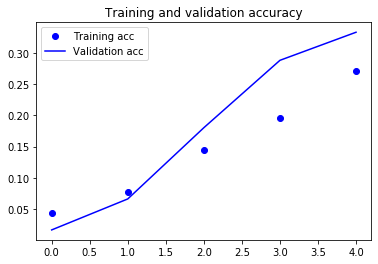

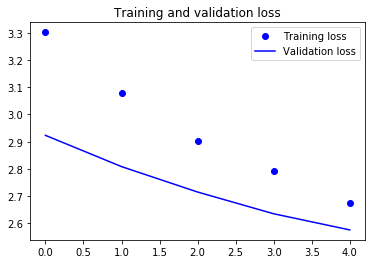

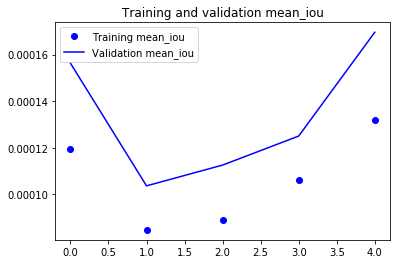

In [25]:
import matplotlib.pyplot as plt

acc = his.history['Comb_output_acc']
val_acc = his.history['val_Comb_output_acc']
loss = his.history['Comb_output_loss']
val_loss = his.history['val_Comb_output_loss']

mean_iou = his.history['Comb_output_mean_iou']
val_mean_iou = his.history['val_Comb_output_mean_iou']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

#plt.savefig("M2 Training and validation accuracy.png")

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

#plt.savefig("M2 Training and validation loss.png")
plt.show()

plt.plot(epochs, mean_iou, 'bo', label='Training mean_iou')
plt.plot(epochs, val_mean_iou, 'b', label='Validation mean_iou')
plt.title('Training and validation mean_iou')
plt.legend()

#plt.savefig("M2 Training and validation mean_iou.png")
plt.show()